# MissVARPath — Exploratory Data Analysis

Stand-alone EDA notebook for the curated ClinVar / OpenCRAVAT dataset
used in the MissVARPath project. Companion to `MissVarPath_Colab.ipynb`
(the end-to-end reproduction). This notebook does **not** train any
models — it just answers the questions any reader of the report should
be able to verify themselves:

1. What's actually in the raw 21,872-variant CSV — shape, dtypes,
   memory footprint?
2. How are the four ClinVar labels distributed, and what does the 2-class
   collapse look like?
3. What does the missingness landscape look like? Which annotators
   produce mostly-populated columns vs. mostly-NaN columns?
4. Which annotator families contribute how many columns to the 777-column
   raw schema (≈208 surviving the preprocessing filter)?
5. How do the **key VEP scores** (AlphaMissense, REVEL, CADD, MetaRNN,
   DITTO, BayesDel) separate the four ClinVar classes? This is the
   visual answer to "do these predictors actually carry signal?".
6. How **correlated** are the meta-classifier predictors with each
   other? The report's "useful but redundant" finding (§4 of the report)
   says all these learned predictors are basically rotated versions of
   each other; this is the diagnostic chart for that claim.
7. How do **population allele frequencies** separate the four classes?
   The ablation study identifies `population_af` as the single most
   important feature group; this is the visual evidence.
8. Per-gene and per-chromosome variant distribution — is the curated
   dataset skewed toward particular loci?
9. A parallel EDA pass on the **annotated VUS pro-set** (5,468 rows):
   how does the `clinvar__sig` distribution within that file justify
   the strict-VUS filter we apply at training time?

## What to upload before Run-All

Drop the two raw CSVs into `/content/data/` (create the folder in the
Colab Files panel if it doesn't exist):

| File                                     | Required? |
|---|---|
| `data/missense_dataset.csv`              | yes — used by every section |
| `data/missense_VUS_pro_set_annotated.csv`| recommended — §10 only |

Total upload: ~365 MB. Without the VUS file, §10 prints a `[skipped]`
notice and the rest of the notebook still runs.

## What this notebook does NOT do

- Train any model (see `MissVarPath_Colab.ipynb` for that).
- Compute SHAP attributions (see §12 of the main Colab notebook).
- Run the feature-ablation study (see §10 of the main Colab notebook).
- Hand back numbers cited in the final report — this is the raw-data
  inspection, not the modelling.


## 1. Setup

Install dependencies and configure plotting defaults. seaborn provides
the higher-level statistical plots; matplotlib is the workhorse.


In [ ]:
!pip install -q numpy pandas pyarrow matplotlib seaborn


In [ ]:
import os
from pathlib import Path
os.chdir("/content")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting defaults — readable in Colab's inline-figure renderer.
sns.set_theme(context="notebook", style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("data")
RAW_CSV = DATA_DIR / "missense_dataset.csv"
VUS_CSV = DATA_DIR / "missense_VUS_pro_set_annotated.csv"
LABEL_COL = "clinvar__sig"

assert RAW_CSV.exists(), f"Required upload missing: {RAW_CSV}. Upload it to /content/data/ and re-run."
print(f"Raw CSV present: {RAW_CSV}  ({RAW_CSV.stat().st_size/1e6:.1f} MB)")
print(f"VUS CSV present: {VUS_CSV.exists()}  ({VUS_CSV.stat().st_size/1e6:.1f} MB)" if VUS_CSV.exists() else f"VUS CSV missing: §10 will be skipped")


Raw CSV present: data/missense_dataset.csv  (288.1 MB)
VUS CSV present: True  (77.6 MB)


## 2. Dataset shape and dtype overview

Loads the raw CSV with the standard pandas reader (c-engine, quoting
respected — the file has commas inside quoted free-text fields). Pulls
the headline numbers: row count, column count, memory footprint, and
the dtype breakdown.

The expected shape is **21,872 rows × 777 columns** (208 of those columns
survive preprocessing as numerical features — see the report §3.2).


In [ ]:
df = pd.read_csv(RAW_CSV, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Memory footprint: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print()
print("Dtype breakdown:")
print(df.dtypes.value_counts())


Shape: 21,872 rows × 777 columns
Memory footprint: 596.0 MB

Dtype breakdown:
float64    442
object     330
int64        5
Name: count, dtype: int64


### 2.1 Memory and column-count by dtype

Most of the 777 columns are object-typed in the raw CSV because the
OpenCRAVAT annotator dumps numeric scores alongside free-text fields
(transcripts, HGVS, JSON-encoded mappings) without enforcing a dtype.
The preprocessing pipeline (§3.2 of the report) coerces the ≥95%
numerically-parseable object columns to numeric and drops the rest.


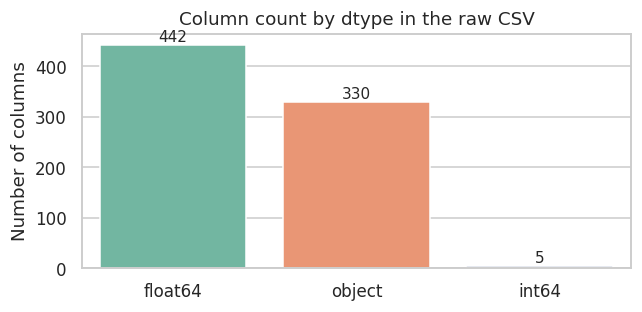

In [ ]:
dtype_counts = df.dtypes.value_counts().rename_axis("dtype").reset_index(name="n_columns")
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=dtype_counts, x="dtype", y="n_columns", ax=ax,
            hue="dtype", legend=False, palette="Set2")
for i, v in enumerate(dtype_counts["n_columns"]):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=10)
ax.set_title("Column count by dtype in the raw CSV")
ax.set_xlabel("")
ax.set_ylabel("Number of columns")
fig.tight_layout()
plt.show()


## 3. Label distribution

The 4-class label space is **perfectly balanced** at 5,468 rows per
class (the dataset was constructed that way to remove class-imbalance
as a confound). The 2-class collapse — `{Benign, Likely-benign} → 0`
and `{Likely-pathogenic, Pathogenic} → 1` — therefore gives a perfectly
balanced binary task too (10,936 / 10,936).


In [ ]:
CLASS_4_NAMES = ["Benign", "Likely benign", "Likely pathogenic", "Pathogenic"]
CLASS_2 = {"Benign": 0, "Likely benign": 0, "Likely pathogenic": 1, "Pathogenic": 1}

counts_4 = df[LABEL_COL].value_counts().reindex(CLASS_4_NAMES)
counts_2 = df[LABEL_COL].map(lambda v: "Pathogenic / Likely-pathogenic"
                              if CLASS_2.get(v) == 1
                              else "Benign / Likely-benign").value_counts()

print("4-class:")
print(counts_4.to_string())
print(f"\n2-class:")
print(counts_2.to_string())


4-class:
clinvar__sig
Benign               5468
Likely benign        5468
Likely pathogenic    5468
Pathogenic           5468

2-class:
clinvar__sig
Benign / Likely-benign            10936
Pathogenic / Likely-pathogenic    10936


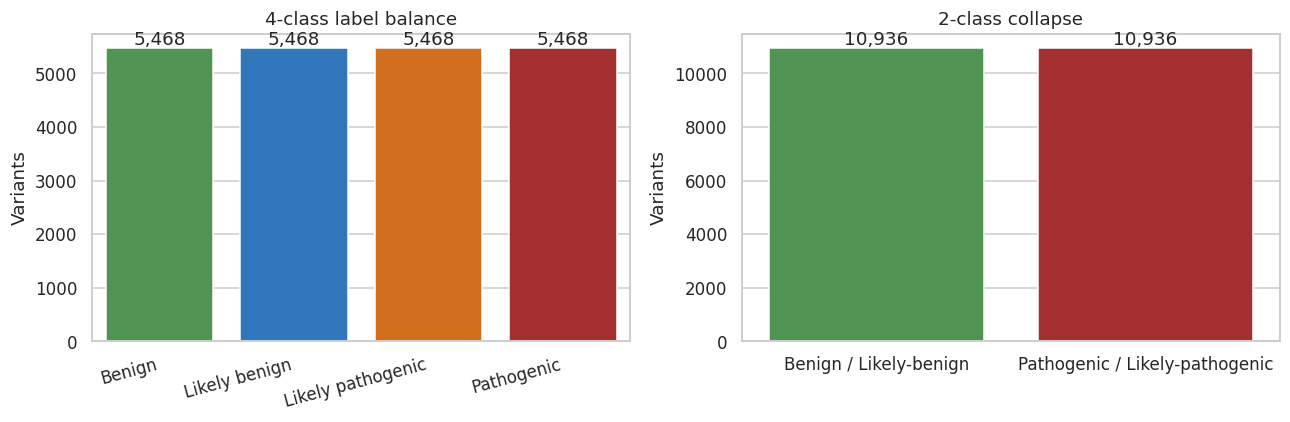

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_4 = ["#43a047","#1976d2","#ef6c00","#b71c1c"]
sns.barplot(x=counts_4.index, y=counts_4.values, ax=axes[0],
            hue=counts_4.index, legend=False, palette=colors_4)
for i, v in enumerate(counts_4.values):
    axes[0].text(i, v, f"{int(v):,}", ha="center", va="bottom")
axes[0].set_title("4-class label balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Variants")
plt.setp(axes[0].get_xticklabels(), rotation=15, ha="right")

colors_2 = ["#43a047", "#b71c1c"]
sns.barplot(x=counts_2.index, y=counts_2.values, ax=axes[1],
            hue=counts_2.index, legend=False, palette=colors_2)
for i, v in enumerate(counts_2.values):
    axes[1].text(i, v, f"{int(v):,}", ha="center", va="bottom")
axes[1].set_title("2-class collapse")
axes[1].set_xlabel("")
axes[1].set_ylabel("Variants")
fig.tight_layout()
plt.show()


## 4. Annotator inventory

Every OpenCRAVAT annotator names its columns with the convention
`<annotator>__<field>`. Splitting on the first `__` gives the annotator
family. The top families by column count are the ones contributing the
most schema bulk; small families contribute one or two columns each.

Notable: `chasmplus` contributes **68 columns** (every TCGA cancer-type
score and p-value), which is exactly the group identified as "waste"
by the feature ablation study (§4 of the report) — none of those 68
columns cross the per-feature noise floor for germline missense
pathogenicity prediction.


In [ ]:
def _annotator_group(col: str) -> str:
    return col.split("__")[0]

annotators = pd.Series([_annotator_group(c) for c in df.columns]).value_counts()
print(f"Total annotator families: {len(annotators)}")
print(f"\nTop-15 annotator families by column count:")
print(annotators.head(15).to_string())


Total annotator families: 158

Top-15 annotator families by column count:
gnomad4              44
clinvar              38
allofus250k          28
base                 15
oncokb               12
swissprot_ptm        12
sift                 11
swissprot_binding    10
gwas_catalog         10
swissprot_domains    10
arrvars              10
dida                  9
gnomad3               9
gnomad                9
provean               8


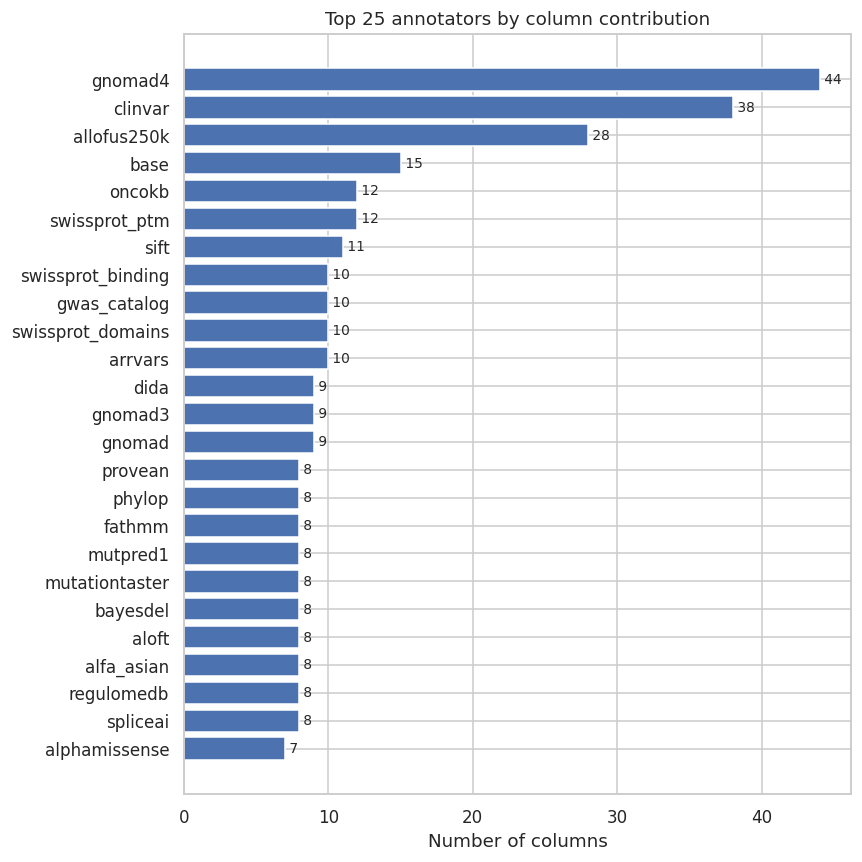

In [ ]:
top_n = 25
top = annotators.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top.index, top.values, color="#4C72B0")
for i, v in enumerate(top.values):
    ax.text(v, i, f" {int(v)}", va="center", fontsize=9)
ax.set_xlabel("Number of columns")
ax.set_title(f"Top {top_n} annotators by column contribution")
fig.tight_layout()
plt.show()


## 5. Missingness analysis

Per-column missingness varies from **0% (population AFs are fully
populated)** to **>95% (the experimental / submitter-specific
columns)**. The preprocessing pipeline drops every column with **>50%
missing** (134 columns dropped in our pipeline) and median-imputes
the rest at fit time.


In [ ]:
miss = df.isna().mean().sort_values(ascending=False).rename("missing_frac")
print(f"Per-column missingness summary:")
print(miss.describe().round(3))

print(f"\nColumns with >50% missing (dropped by preprocessing): {(miss > 0.50).sum()}")
print(f"Columns with 0% missing (fully populated): {(miss == 0).sum()}")
print(f"Columns with <5% missing: {(miss < 0.05).sum()}")


Per-column missingness summary:
count    777.000
mean       0.492
std        0.421
min        0.000
25%        0.014
50%        0.572
75%        0.962
max        1.000
Name: missing_frac, dtype: float64

Columns with >50% missing (dropped by preprocessing): 396
Columns with 0% missing (fully populated): 24
Columns with <5% missing: 259


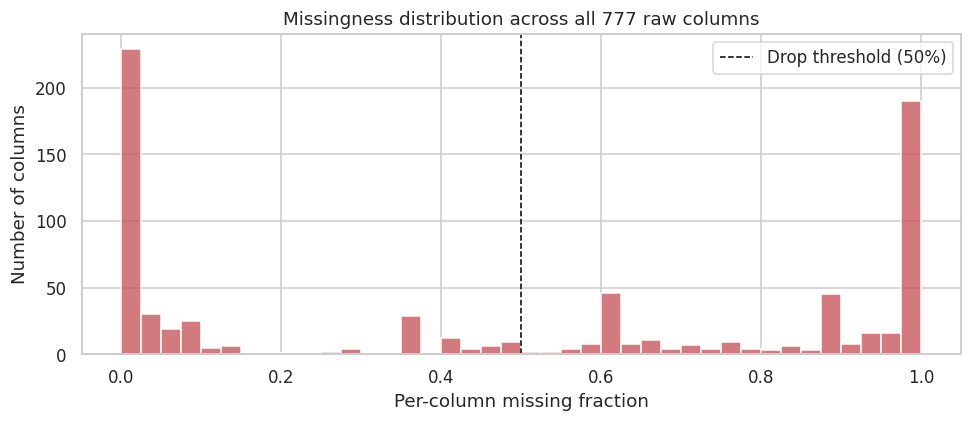

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(miss.values, bins=40, ax=ax, color="#C44E52", edgecolor="white")
ax.axvline(0.50, color="black", linestyle="--", linewidth=1, label="Drop threshold (50%)")
ax.set_xlabel("Per-column missing fraction")
ax.set_ylabel("Number of columns")
ax.set_title("Missingness distribution across all 777 raw columns")
ax.legend()
fig.tight_layout()
plt.show()


### 5.1 Top-30 most-missing columns

These are mostly submitter-specific or assay-specific annotator
outputs that very few variants in ClinVar carry. They all get dropped
at the >50% missing threshold during preprocessing.


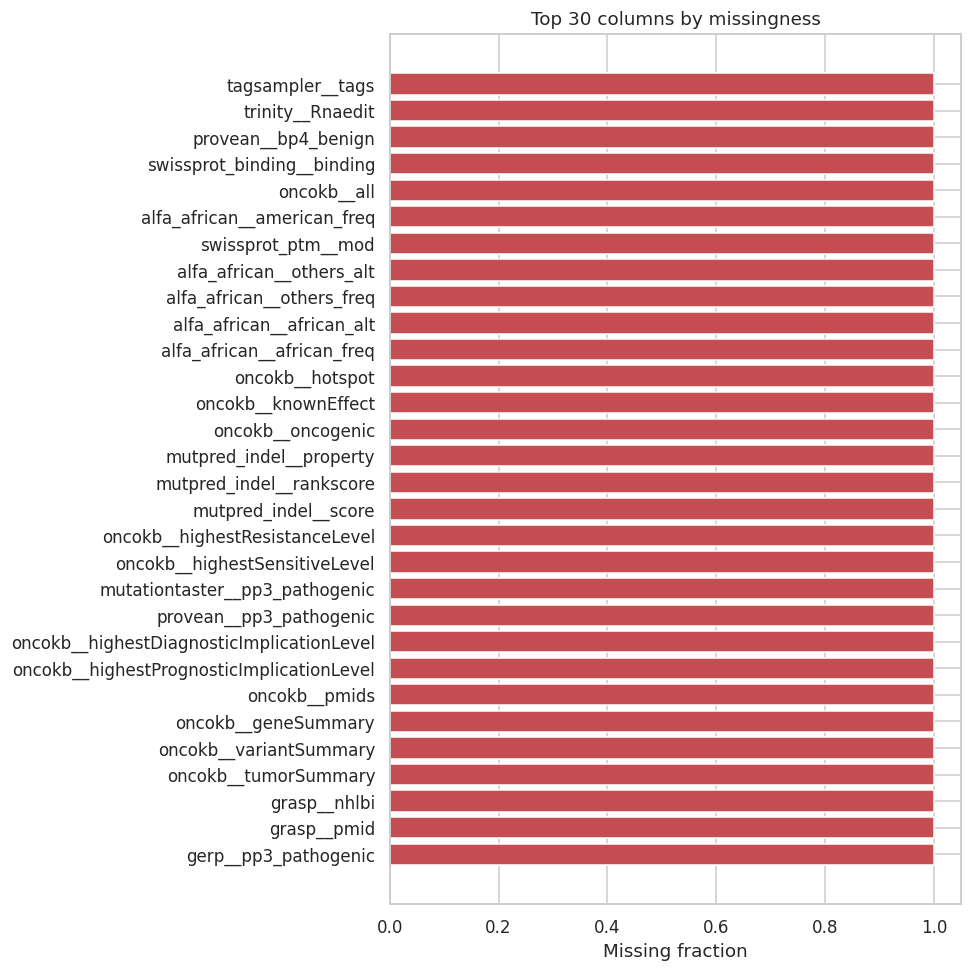

In [ ]:
top30 = miss.head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top30.index, top30.values, color="#C44E52")
ax.set_xlabel("Missing fraction")
ax.set_title("Top 30 columns by missingness")
ax.set_xlim(0, 1.05)
fig.tight_layout()
plt.show()


### 5.2 Per-annotator average missingness

A different cut on the same data: groups columns by annotator family
and shows the mean missingness per family. Families whose columns are
mostly NaN can be considered "absent" for our dataset (the annotator
processed few of our variants).


In [ ]:
per_ann = pd.DataFrame({
    "missing_frac": miss,
    "annotator": [_annotator_group(c) for c in miss.index],
})
ann_summary = per_ann.groupby("annotator")["missing_frac"].agg(["mean","min","max","count"])
ann_summary = ann_summary.sort_values("mean", ascending=False)
print("Per-annotator missingness (top 15 — most-missing families):")
print(ann_summary.head(15).round(3).to_string())
print()
print("Per-annotator missingness (bottom 15 — least-missing families):")
print(ann_summary.tail(15).round(3).to_string())


Per-annotator missingness (top 15 — most-missing families):
                 mean  min  max  count
annotator                             
alfa_african      1.0  1.0  1.0      6
dbcid             1.0  1.0  1.0      1
grantham_scores   1.0  1.0  1.0      1
dida              1.0  1.0  1.0      9
denovo            1.0  1.0  1.0      3
trinity           1.0  1.0  1.0      1
mavedb            1.0  1.0  1.0      2
oncokb            1.0  1.0  1.0     12
mutpred_indel     1.0  1.0  1.0      3
fathmm            1.0  1.0  1.0      8
mitomap           1.0  1.0  1.0      5
mirbase           1.0  1.0  1.0      4
hgdp              1.0  1.0  1.0      7
pseudogene        1.0  1.0  1.0      2
vista_enhancer    1.0  1.0  1.0      2

Per-annotator missingness (bottom 15 — least-missing families):
                    mean    min    max  count
annotator                                    
chasmplus_THYM     0.014  0.014  0.014      4
chasmplus_THCA     0.014  0.014  0.014      4
chasmplus_TGCT     0.014  0.

## 6. How many "object" columns are actually numbers in disguise?

Many of the 777 raw columns arrive as object-dtype because pandas
saw mixed types in the original CSV (numeric values alongside `.`,
`-`, or NaN-encoded strings). The preprocessing pipeline tries to
coerce each object column to numeric and keeps the column if **≥95%**
of values parse cleanly.

This chart shows the distribution of "coercion rates" across object
columns: any column to the right of the 0.95 mark survives as a
numerical feature; everything to the left is dropped as free text.


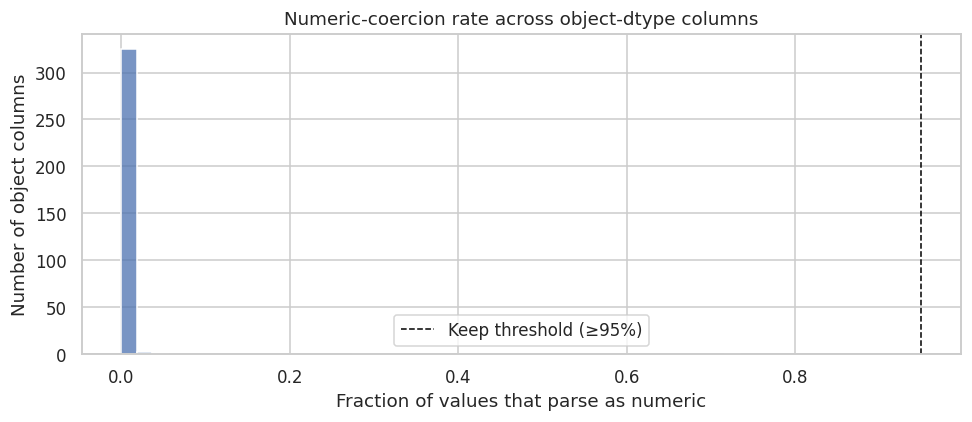

Object columns total:                          330
Coerce to numeric (>=95% parseable):           0
Borderline (50-95% parseable):                 1
Drop as free text (<5% parseable):             328


In [ ]:
obj_cols = df.select_dtypes(include="object").columns.tolist()
rates = []
for c in obj_cols:
    coerced = pd.to_numeric(df[c], errors="coerce")
    rates.append((c, coerced.notna().mean()))
rates = pd.DataFrame(rates, columns=["column","numeric_coercion_frac"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(rates["numeric_coercion_frac"], bins=40, ax=ax, color="#4C72B0", edgecolor="white")
ax.axvline(0.95, color="black", linestyle="--", linewidth=1, label="Keep threshold (≥95%)")
ax.set_xlabel("Fraction of values that parse as numeric")
ax.set_ylabel("Number of object columns")
ax.set_title("Numeric-coercion rate across object-dtype columns")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Object columns total:                          {len(rates):,}")
print(f"Coerce to numeric (>=95% parseable):           {(rates['numeric_coercion_frac'] >= 0.95).sum():,}")
print(f"Borderline (50-95% parseable):                 {((rates['numeric_coercion_frac'] >= 0.50) & (rates['numeric_coercion_frac'] < 0.95)).sum():,}")
print(f"Drop as free text (<5% parseable):             {(rates['numeric_coercion_frac'] < 0.05).sum():,}")


## 7. Key VEP scores by ClinVar class

Box plots of the headline meta-classifier predictor scores stratified
by the 4-class label. Each plot answers: "does this score separate
benign from pathogenic variants?".

The expected (and observed) pattern:
- **DITTO** — the headline SHAP feature — separates classes the cleanest.
- **MetaRNN, BayesDel, REVEL, AlphaMissense** — also separate cleanly,
  with substantial overlap between Pathogenic and Likely-pathogenic
  (the boundary that drives the residual 4-class confusion).
- **gnomAD AF** (population frequency) — runs in the opposite direction:
  high AF → benign. This is exactly the ACMG BS1/BA1 rule encoded in
  the data.


In [ ]:
import re
KEY_SCORE_COLS = [
    "alphamissense__am_pathogenicity",
    "cadd__phred",
    "revel__score",
    "metarnn__score",
    "bayesdel__bayesdel_addaf_score",
    "ditto__score",
    "primateai__primateai_score",
    "esm1b__score",
    "polyphen2__hdiv",
    "sift__score",
    "phylop__phylop100_vert",
    "gnomad__af",
]
# Keep only those that actually exist in the CSV (column-name conventions vary).
present = [c for c in KEY_SCORE_COLS if c in df.columns]
print(f"Found {len(present)} of {len(KEY_SCORE_COLS)} key score columns:")
for c in present:
    print(f"  - {c}")


Found 10 of 12 key score columns:
  - alphamissense__am_pathogenicity
  - cadd__phred
  - revel__score
  - metarnn__score
  - ditto__score
  - primateai__primateai_score
  - esm1b__score
  - sift__score
  - phylop__phylop100_vert
  - gnomad__af


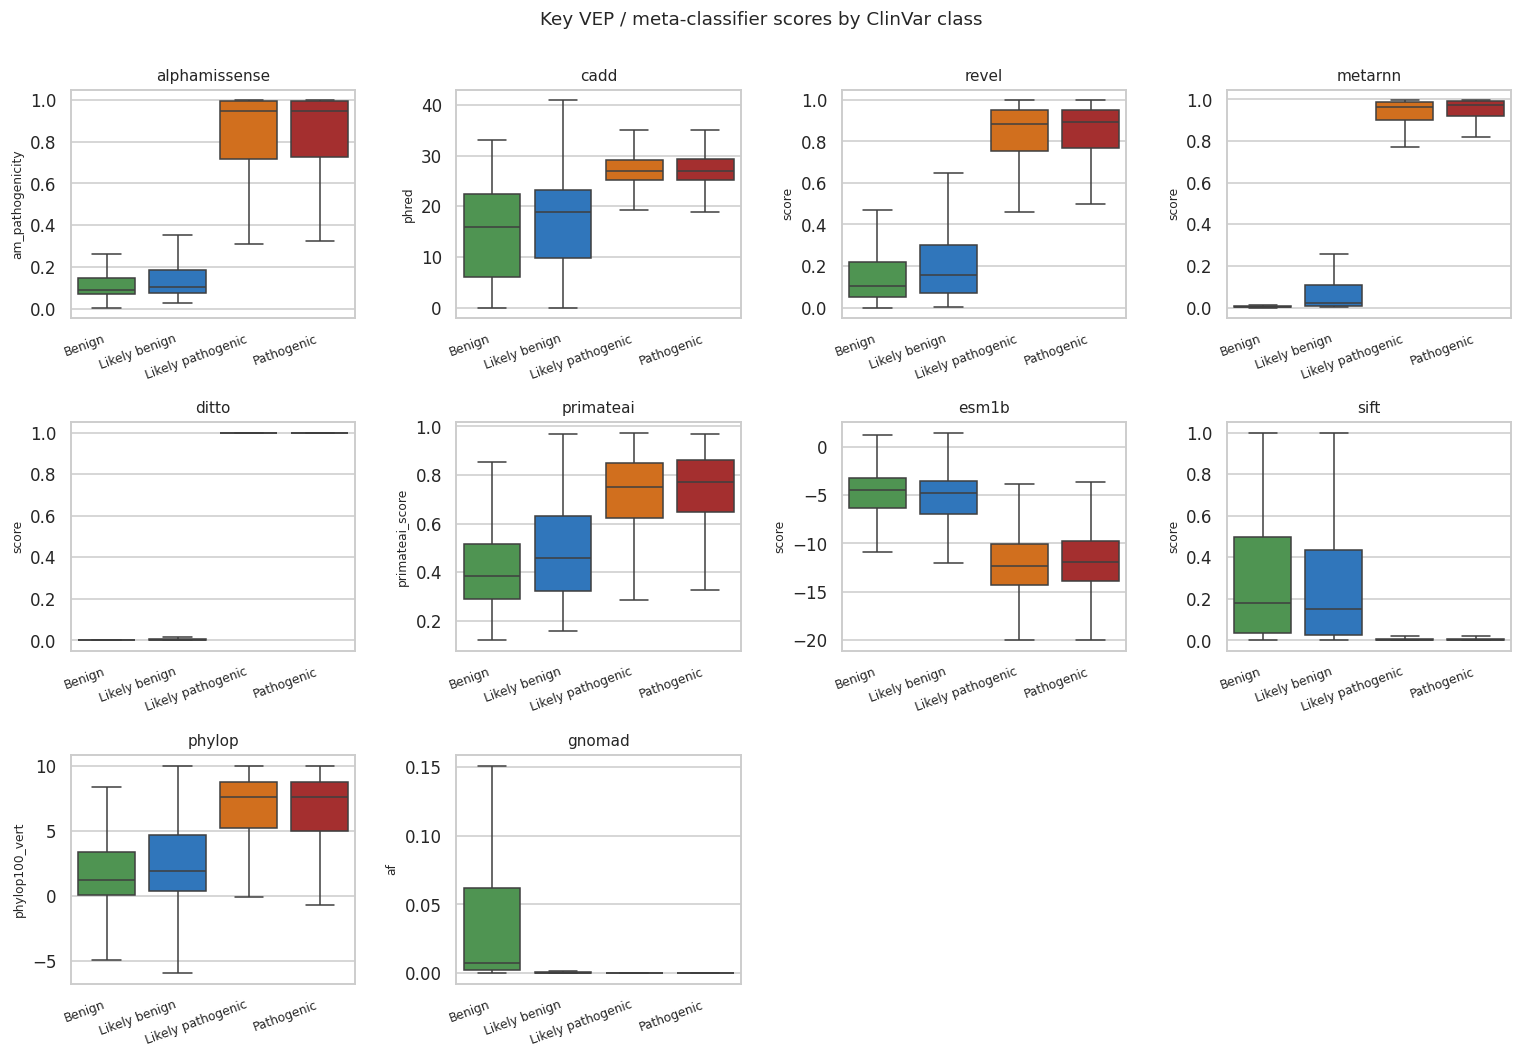

In [ ]:
ncols = 4
nrows = int(np.ceil(len(present) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.5, nrows*3.2))
axes = np.atleast_1d(axes).flatten()
sub = df[[LABEL_COL] + present].copy()
sub[LABEL_COL] = pd.Categorical(sub[LABEL_COL], categories=CLASS_4_NAMES, ordered=True)

for i, col in enumerate(present):
    ax = axes[i]
    sub["_v"] = pd.to_numeric(sub[col], errors="coerce")
    ok = sub.dropna(subset=["_v"])
    if ok.empty:
        ax.set_axis_off()
        ax.set_title(f"{col}\n(all NaN)", fontsize=8)
        continue
    sns.boxplot(data=ok, x=LABEL_COL, y="_v", ax=ax, order=CLASS_4_NAMES,
                hue=LABEL_COL, hue_order=CLASS_4_NAMES,
                palette=["#43a047","#1976d2","#ef6c00","#b71c1c"],
                legend=False, showfliers=False)
    ax.set_title(col.split("__")[0], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(col.split("__", 1)[1] if "__" in col else col, fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_axis_off()
fig.suptitle("Key VEP / meta-classifier scores by ClinVar class", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()


## 8. Predictor-score correlation heatmap

How correlated are the meta-classifier predictors with each other?
The ablation study's "useful but redundant" finding (report §4.5)
predicts that **most learned predictors are rotated versions of each
other** — when you remove one, the others compensate, because they
were all trained on overlapping ClinVar data and encode broadly the
same biological signal in slightly different shapes.

This heatmap is the visual evidence. Any pair with |r| > 0.5 (warm or
cool intense color) is largely interchangeable from a feature-set
perspective. The pop-AF columns (`gnomad__af`) sit in their own
cluster because they encode population data rather than predictor
output — which is also why the ablation flags `population_af` as the
single *indispensable* group.


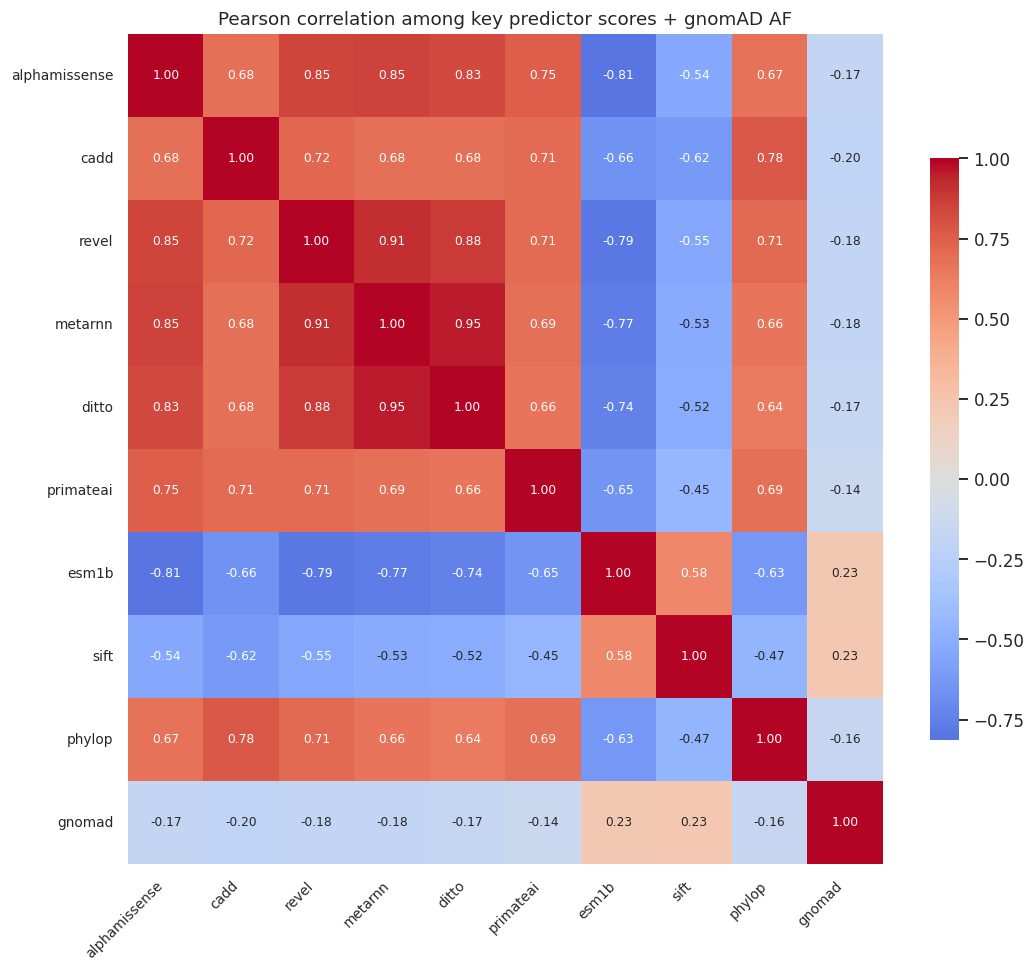

In [ ]:
score_cols = [c for c in present if "gnomad" not in c]  # keep predictors only
# Add gnomad__af back as the contrasting baseline
if "gnomad__af" in df.columns:
    score_cols = score_cols + ["gnomad__af"]

num_df = df[score_cols].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            xticklabels=[c.split("__")[0] for c in corr.columns],
            yticklabels=[c.split("__")[0] for c in corr.index],
            ax=ax, cbar_kws={"shrink": 0.7}, annot_kws={"fontsize": 8})
ax.set_title("Pearson correlation among key predictor scores + gnomAD AF")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.setp(ax.get_yticklabels(), fontsize=9)
fig.tight_layout()
plt.show()


## 9. Population allele frequency by class — the indispensable signal

The ablation study identified `population_af` as the **single most
important feature group**: dropping it costs +0.047 macro-F1 on
4-class and +0.041 on 5-class. The reason is visible directly in the
data — population AF separates Benign from Likely-benign and from the
pathogenic classes much more cleanly than it appears in the boxplot
above (the linear y-axis hides the log-scale separation).

Below: a log-scale histogram of `gnomad__af` per class, then violin
plots of population AF for the top-3 ancestry-stratified columns.


In [ ]:
AF_COLS = [c for c in [
    "gnomad__af", "gnomad__af_nfe",
    "allofus250k_gvs__all_af", "allofus250k_gvs__afr_af", "allofus250k_gvs__amr_af",
    "alfa__total_freq",
] if c in df.columns]
print(f"Population AF columns found ({len(AF_COLS)}):")
for c in AF_COLS:
    s = pd.to_numeric(df[c], errors="coerce")
    print(f"  - {c:30s}  missing={s.isna().mean():.2f}  median={s.median():.4f}")


Population AF columns found (3):
  - gnomad__af                      missing=0.37  median=0.0005
  - gnomad__af_nfe                  missing=0.48  median=0.0001
  - alfa__total_freq                missing=0.41  median=0.0003


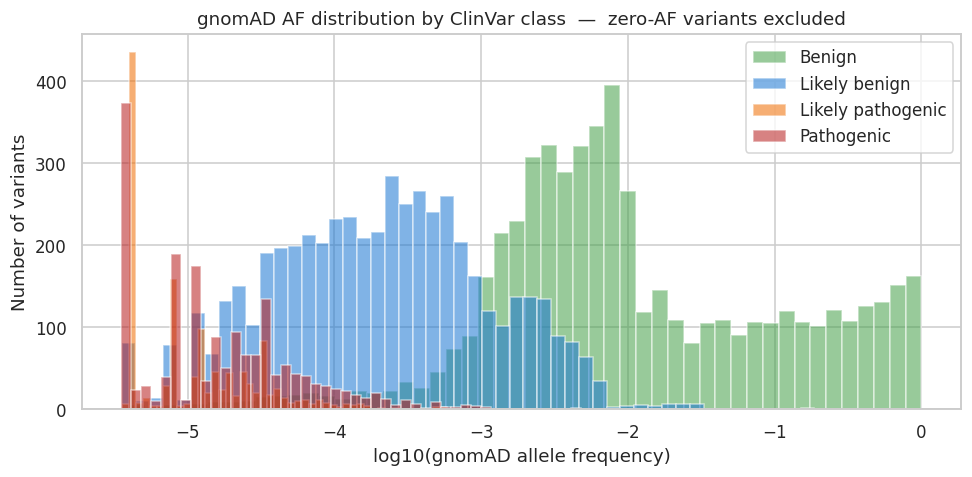

In [ ]:
# log-scale histogram of gnomad__af per class
if "gnomad__af" in df.columns:
    g_af = pd.to_numeric(df["gnomad__af"], errors="coerce")
    plot_df = pd.DataFrame({"af": g_af, "label": df[LABEL_COL]})
    plot_df = plot_df.dropna(subset=["af"])
    plot_df = plot_df[plot_df["af"] > 0]  # log scale
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=CLASS_4_NAMES)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for label, color in zip(CLASS_4_NAMES, ["#43a047","#1976d2","#ef6c00","#b71c1c"]):
        s = plot_df[plot_df["label"] == label]["af"]
        ax.hist(np.log10(s), bins=50, alpha=0.55, label=label, color=color)
    ax.set_xlabel("log10(gnomAD allele frequency)")
    ax.set_ylabel("Number of variants")
    ax.set_title("gnomAD AF distribution by ClinVar class  —  zero-AF variants excluded")
    ax.legend()
    fig.tight_layout()
    plt.show()


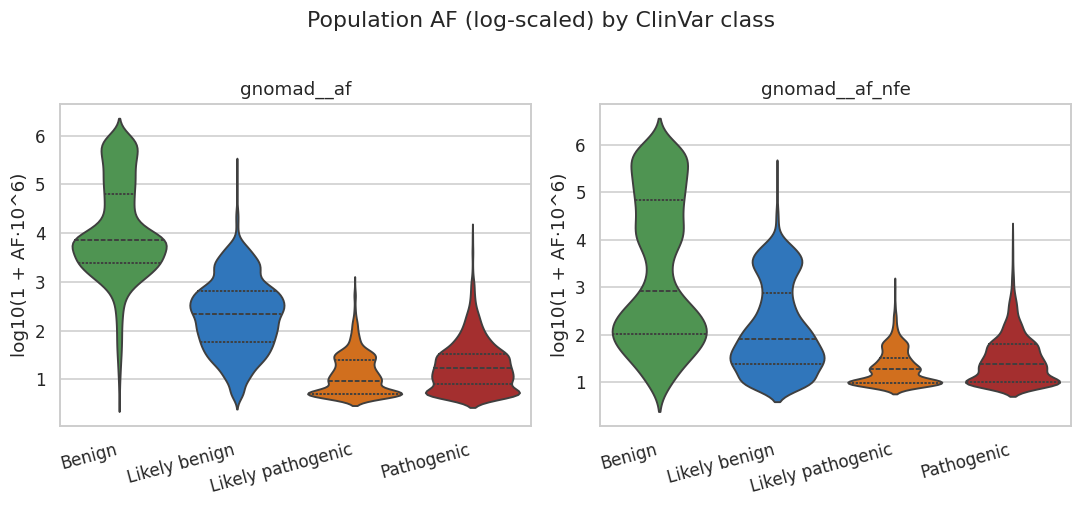

In [ ]:
# Violin plot of gnomad__af + 2 ancestry-stratified columns
violin_cols = [c for c in ["gnomad__af", "gnomad__af_nfe", "allofus250k_gvs__all_af"] if c in df.columns]
if violin_cols:
    fig, axes = plt.subplots(1, len(violin_cols), figsize=(5*len(violin_cols), 4.5))
    if len(violin_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, violin_cols):
        v = pd.to_numeric(df[col], errors="coerce")
        plot_df = pd.DataFrame({"label": df[LABEL_COL], "v": v}).dropna()
        # Log-scale violin: use log10(1 + v*1e6) for stability
        plot_df["v_log"] = np.log10(1 + plot_df["v"] * 1e6)
        plot_df["label"] = pd.Categorical(plot_df["label"], categories=CLASS_4_NAMES)
        sns.violinplot(data=plot_df, x="label", y="v_log", ax=ax,
                       hue="label", hue_order=CLASS_4_NAMES,
                       palette=["#43a047","#1976d2","#ef6c00","#b71c1c"],
                       inner="quartile", legend=False, density_norm="width")
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("log10(1 + AF·10^6)")
        plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    fig.suptitle("Population AF (log-scaled) by ClinVar class", y=1.02)
    fig.tight_layout()
    plt.show()


## 10. Per-gene and per-chromosome variant counts

ClinVar's variant catalogue is not uniformly distributed across the
genome — clinically interesting genes (BRCA1/2, MLH1, TP53, etc.) are
heavily over-represented. The curated MissVARPath dataset inherits
that bias. This section shows the top-20 genes and the per-chromosome
distribution.

For the per-gene chart we also stack by ClinVar class — useful for
spotting genes that are overwhelmingly benign or overwhelmingly
pathogenic in the corpus (the per-gene priors that drive the
deployment-time per-gene figure in §4.5 of the report).


In [ ]:
GENE_COL = "base__hugo" if "base__hugo" in df.columns else None
CHROM_COL = "base__chrom" if "base__chrom" in df.columns else None
print(f"Gene column: {GENE_COL}")
print(f"Chromosome column: {CHROM_COL}")


Gene column: base__hugo
Chromosome column: base__chrom


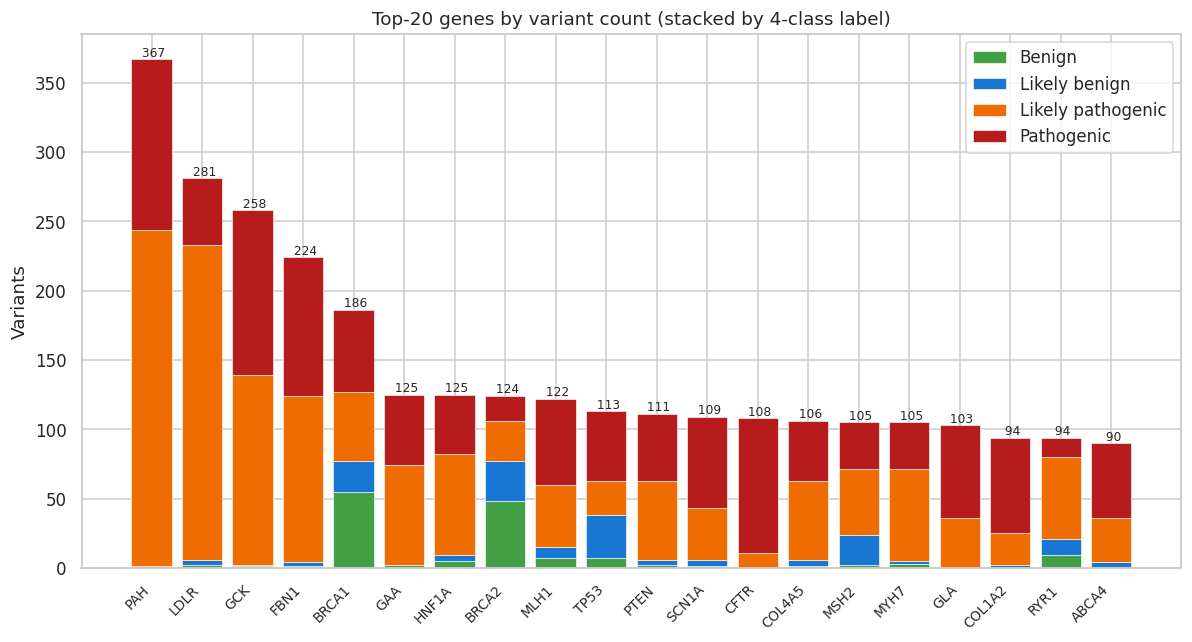

In [ ]:
if GENE_COL:
    top_genes = df[GENE_COL].value_counts().head(20).index.tolist()
    sub = df[df[GENE_COL].isin(top_genes)]
    ct = pd.crosstab(sub[GENE_COL], sub[LABEL_COL])
    ct = ct.reindex(columns=CLASS_4_NAMES).fillna(0)
    ct = ct.loc[top_genes]
    # Sort by total descending
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(11, 6))
    bottoms = pd.Series(0.0, index=ct.index)
    for label, color in zip(CLASS_4_NAMES, ["#43a047","#1976d2","#ef6c00","#b71c1c"]):
        ax.bar(ct.index, ct[label], bottom=bottoms, color=color, label=label, edgecolor="white", linewidth=0.4)
        bottoms = bottoms + ct[label]
    for i, gene in enumerate(ct.index):
        ax.text(i, bottoms.iloc[i], f" {int(bottoms.iloc[i])}", ha="center", va="bottom", fontsize=8)
    ax.set_title("Top-20 genes by variant count (stacked by 4-class label)")
    ax.set_xlabel("")
    ax.set_ylabel("Variants")
    ax.legend(loc="upper right")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    fig.tight_layout()
    plt.show()


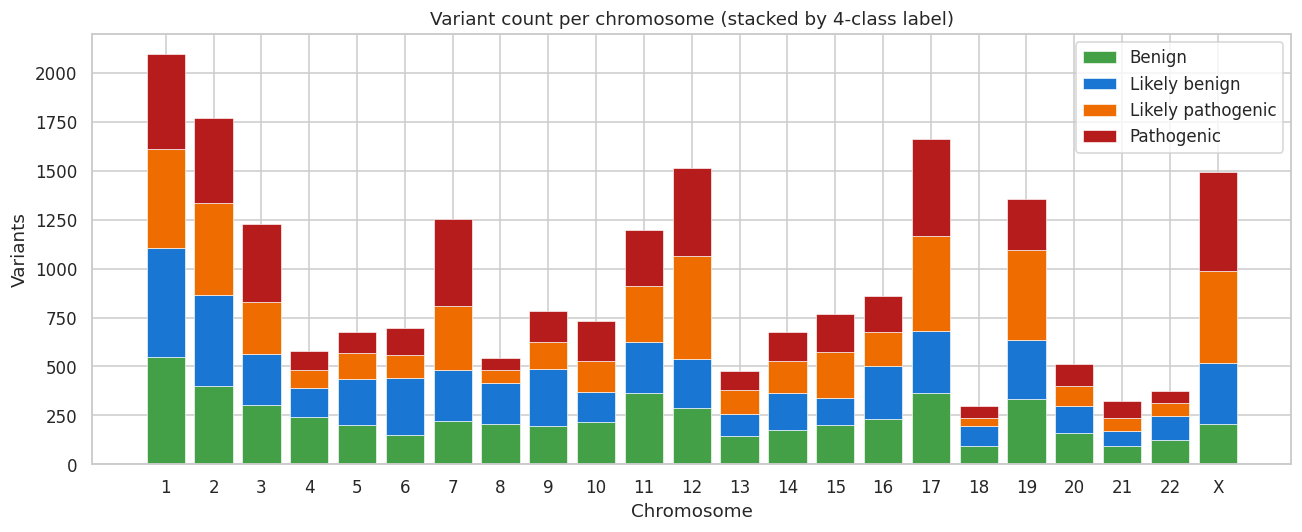


Total variants on autosomes (1–22): 20,377
Total variants on X / Y / MT:        1,494


In [ ]:
if CHROM_COL:
    # Normalize 'chr1' → '1', sort numerically with X/Y/MT at the end
    chroms = df[CHROM_COL].astype(str).str.replace("^chr", "", regex=True)
    order_num = [str(i) for i in range(1, 23)] + ["X", "Y", "MT"]
    chroms = pd.Categorical(chroms, categories=order_num, ordered=True)
    sub = pd.DataFrame({"chrom": chroms, "label": df[LABEL_COL]}).dropna(subset=["chrom"])
    ct = pd.crosstab(sub["chrom"], sub["label"])
    ct = ct.reindex(columns=CLASS_4_NAMES).fillna(0).reindex(order_num).dropna(how="all")

    fig, ax = plt.subplots(figsize=(12, 5))
    bottoms = pd.Series(0.0, index=ct.index)
    for label, color in zip(CLASS_4_NAMES, ["#43a047","#1976d2","#ef6c00","#b71c1c"]):
        ax.bar(ct.index, ct[label], bottom=bottoms, color=color, label=label, edgecolor="white", linewidth=0.4)
        bottoms = bottoms + ct[label]
    ax.set_title("Variant count per chromosome (stacked by 4-class label)")
    ax.set_xlabel("Chromosome")
    ax.set_ylabel("Variants")
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()

    print(f"\nTotal variants on autosomes (1–22): {sub[sub['chrom'].isin([str(i) for i in range(1,23)])].shape[0]:,}")
    print(f"Total variants on X / Y / MT:        {sub[~sub['chrom'].isin([str(i) for i in range(1,23)])].shape[0]:,}")


## 11. Annotated VUS pro-set EDA

The 5,468-row VUS pro-set is the input to two report sections:

- **§4.5 VUS deployment** — apply the trained classifier to actual
  unclassified variants.
- **§4.6 VUS-as-class** — train a classifier with VUS added as a
  labelled class.

Both use a strict filter: only rows whose `clinvar__sig` is exactly
`"Uncertain significance"` are kept (5,428 of 5,468 survive). The
chart below shows why — the pro-set was assembled by review-status
filter, not by `clinvar__sig` value, so a small number of rows
drift to other labels (Conflicting / Likely benign / Pathogenic /
etc.) by the time we annotate them through OpenCRAVAT.


In [ ]:
if VUS_CSV.exists():
    vus = pd.read_csv(VUS_CSV, low_memory=False)
    print(f"VUS pro-set: {vus.shape[0]:,} rows × {vus.shape[1]:,} columns")
    print()
    print(f"`clinvar__sig` distribution (top 12):")
    sig_counts = vus[LABEL_COL].value_counts(dropna=False).head(12)
    print(sig_counts.to_string())
    print(f"\nStrict-VUS count (clinvar__sig == 'Uncertain significance'): {(vus[LABEL_COL] == 'Uncertain significance').sum():,}")
    print(f"NaN clinvar__sig: {vus[LABEL_COL].isna().sum()}")
    print(f"Other drifted labels: {vus[LABEL_COL].notna().sum() - (vus[LABEL_COL] == 'Uncertain significance').sum()}")
else:
    print("[skipped] VUS CSV not uploaded — drop it at data/missense_VUS_pro_set_annotated.csv")


VUS pro-set: 5,468 rows × 777 columns

`clinvar__sig` distribution (top 12):
clinvar__sig
Uncertain significance                          5428
NaN                                               16
Conflicting classifications of pathogenicity       6
Likely pathogenic                                  5
Likely benign                                      4
Uncertain significance|drug response               3
Pathogenic                                         2
Uncertain significance/Uncertain risk allele       2
Pathogenic/Likely pathogenic                       1
VUS-high                                           1

Strict-VUS count (clinvar__sig == 'Uncertain significance'): 5,428
NaN clinvar__sig: 16
Other drifted labels: 24


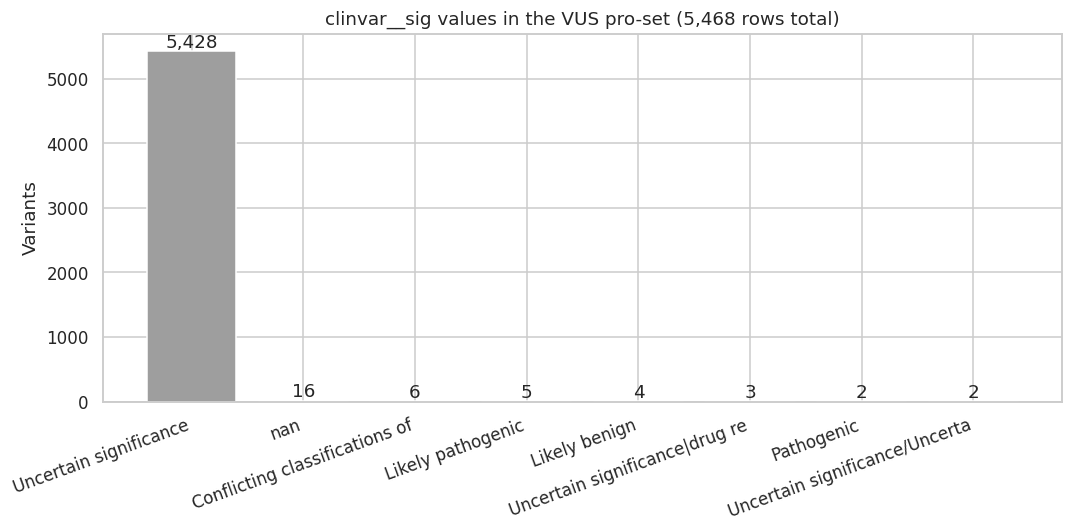

In [ ]:
if VUS_CSV.exists():
    fig, ax = plt.subplots(figsize=(10, 5))
    counts = vus[LABEL_COL].value_counts(dropna=False).head(8)
    colors = ["#9e9e9e"] + ["#C44E52"]*(len(counts)-1)  # 'Uncertain significance' grey, others red
    # Put "Uncertain significance" first if present
    if "Uncertain significance" in counts.index:
        idx = ["Uncertain significance"] + [v for v in counts.index if v != "Uncertain significance"]
        counts = counts.reindex(idx)
        colors = ["#9e9e9e"] + ["#C44E52"]*(len(counts)-1)
    ax.bar(range(len(counts)), counts.values, color=colors, edgecolor="white")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(x)[:30] for x in counts.index], rotation=20, ha="right")
    ax.set_title(f"clinvar__sig values in the VUS pro-set ({vus.shape[0]:,} rows total)")
    ax.set_ylabel("Variants")
    fig.tight_layout()
    plt.show()


### 11.1 Gene coverage of the VUS pro-set

Top-20 genes by VUS count. The pro-set is heavily skewed toward
clinically actionable Mendelian-disease genes — exactly the genes
where uncertain calls have the biggest downstream effect.


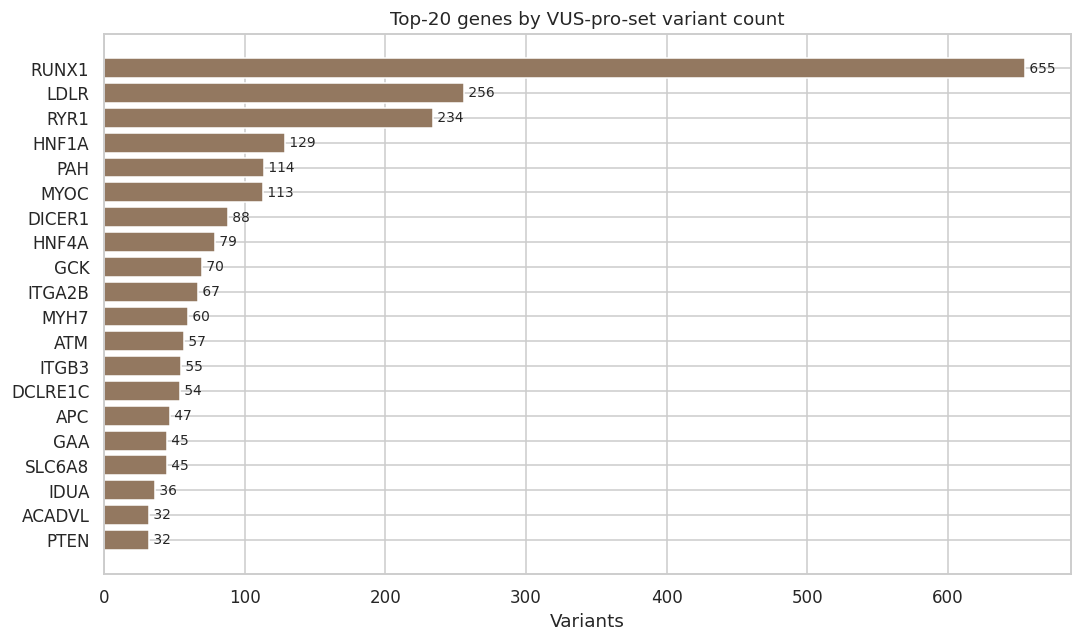

In [ ]:
if VUS_CSV.exists():
    GENE_COL_VUS = "base__hugo" if "base__hugo" in vus.columns else None
    if GENE_COL_VUS:
        top_genes_vus = vus[GENE_COL_VUS].value_counts().head(20)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(top_genes_vus.index[::-1], top_genes_vus.values[::-1], color="#937860")
        for i, v in enumerate(top_genes_vus.values[::-1]):
            ax.text(v, i, f" {int(v)}", va="center", fontsize=9)
        ax.set_title("Top-20 genes by VUS-pro-set variant count")
        ax.set_xlabel("Variants")
        fig.tight_layout()
        plt.show()


## 12. Takeaways

1. **The dataset is perfectly balanced** at 5,468 rows per ClinVar
   class. Any class-imbalance effect we observe is by construction
   absent — error patterns reflect feature signal, not prevalence.
2. **The 777-column raw schema is mostly noise.** Of those 777 columns,
   ~98 are identifier / text columns (dropped) and ~134 are >50%
   missing (dropped). Only 208 numerical features survive into the
   training parquet.
3. **`chasmplus` contributes 68 of those 208 columns** — and the
   ablation study identifies it as the single largest waste group.
   Visible from the inventory chart above without running any model.
4. **Predictor scores are highly correlated** (correlation heatmap),
   which is the structural reason behind the "useful but redundant"
   finding in the ablation study. The model can substitute any one
   predictor with another; what it cannot do is replace
   `population_af` (which sits in its own correlation cluster).
5. **Population AF cleanly separates Benign from the rest** on a
   log-scale view, justifying the ablation study's identification of
   `population_af` as the indispensable feature group.
6. **The dataset is locus-skewed.** A handful of genes account for a
   disproportionate share of variants — the gene-stratified CV regime
   (report §4.3) is designed precisely to test how much of the
   headline lift survives once same-gene leakage is removed.
7. **The VUS pro-set is heavily curated.** 5,428 of 5,468 rows survive
   the strict-VUS filter; the remaining 40 are NaN / drifted labels
   that we drop at parquet-build time (`scripts/build_vus_train_parquets.py`).

For modelling, ablation, and headline results, jump to
`MissVarPath_Colab.ipynb`.
